# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [12]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [13]:
bandit0 = BanditProblem(0)


In [14]:
bandit0.get_num_arms()


3

In [15]:
bandit0.get_reward(arm=0)


1.8255111545554434

In [24]:
num_arms = bandit0.get_num_arms()
num_samples = 3000

samples = {
    arm: np.array([bandit0.get_reward(arm) for _ in range(num_samples)])
    for arm in range(num_arms)
}

for arm in range(num_arms):
    x = samples[arm]
    print(
        f"arm {arm}:"
        f" min={x.min():.4f}"
        f" mean={x.mean():.4f}"
        f" max={x.max():.4f}"
        f" distinct_values={len(np.unique(x))}"
        f" fraction_exactly_zero={np.mean(x == 0):.4f}"
        f" fraction_in_zero_one_set={np.mean(np.isin(x, [0, 1])):.4f}"
    )


arm 0: min=0.0000 mean=0.8455 max=5.8177 distinct_values=2522 fraction_exactly_zero=0.1597 fraction_in_zero_one_set=0.1597
arm 1: min=0.0000 mean=0.5998 max=4.8232 distinct_values=2182 fraction_exactly_zero=0.2730 fraction_in_zero_one_set=0.2730
arm 2: min=0.0000 mean=0.9214 max=4.9967 distinct_values=2687 fraction_exactly_zero=0.1047 fraction_in_zero_one_set=0.1047


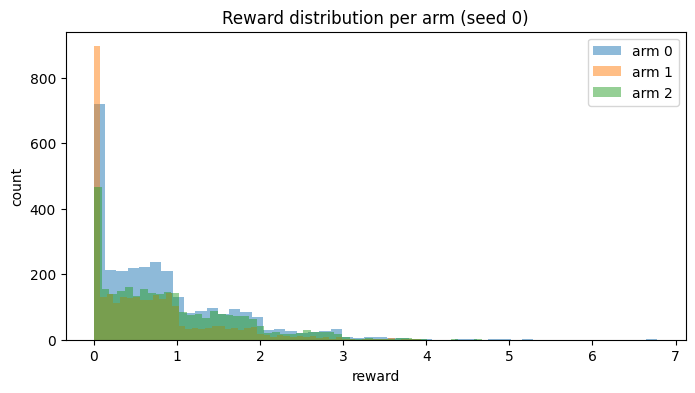

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for arm in range(num_arms):
    ax.hist(samples[arm], bins=50, alpha=0.5, label=f"arm {arm}")
ax.set_xlabel("reward")
ax.set_ylabel("count")
ax.set_title("Reward distribution per arm (seed 0)")
ax.legend()
plt.show()


Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives.
Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [ ]:
def epsilon_greedy(bandit, num_steps=1000, epsilon=0.1, seed=704):
    num_arms = bandit.get_num_arms()

    chooser = np.random.default_rng(seed)

    counts = np.zeros(num_arms, dtype=int)
    totals = np.zeros(num_arms)
    actions = []
    rewards = []

    for t in range(num_steps):
        if t < num_arms:
            action = t
        elif chooser.uniform() < epsilon:
            action = int(chooser.integers(num_arms))  
        else:
            action = int(np.argmax(totals / np.maximum(counts, 1)))  

        reward = bandit.get_reward(action)

        counts[action] += 1
        totals[action] += reward
        actions.append(action)
        rewards.append(reward)

    return np.array(actions), np.array(rewards)


NUM_STEPS = 1000
EPSILON = 0.03

bandit2026 = BanditProblem(2026)
actions, rewards = epsilon_greedy(bandit2026, num_steps=NUM_STEPS, epsilon=EPSILON)

print("actions taken:", len(actions))
print("times each arm was pulled:", np.bincount(actions, minlength=bandit2026.get_num_arms()))
print("total reward:", rewards.sum())


actions taken: 1000
times each arm was pulled: [980  10  10]
total reward: 1193.7995714756478


Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [19]:
import pandas as pd

history = pd.DataFrame({"action": actions, "reward": rewards})
history.to_csv("history.tsv", sep="\t", index=False)

history.head()


,action,reward
0,0,3.162073
1,1,0.177353
2,2,0.298303
3,0,2.759550
4,0,1.505464


Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [20]:
actions_df = (
    history.groupby("action")["reward"]
    .agg(min_reward="min", mean_reward="mean", max_reward="max")
    .reindex(range(bandit2026.get_num_arms()))
    .reset_index()
)

actions_df.to_csv("actions.tsv", sep="\t", index=False)

actions_df


,action,min_reward,mean_reward,max_reward
0,0,0.0,1.213325,6.564312
1,1,0.0,0.272429,0.919950
2,2,0.0,0.201663,0.877962


Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [21]:
mean_rewards = actions_df.set_index("action")["mean_reward"]
best_mean = mean_rewards.max()
num_arms = len(mean_rewards)

strategies = {}

strategies["uniform"] = NUM_STEPS * (best_mean - mean_rewards.mean())

for arm in range(num_arms):
    strategies[f"just-{arm}"] = NUM_STEPS * (best_mean - mean_rewards[arm])

counts = history["action"].value_counts().reindex(range(num_arms), fill_value=0)
strategies["actual"] = NUM_STEPS * best_mean - float((counts * mean_rewards).sum())

for name, regret in strategies.items():
    print(f"{name}: {regret:.4f}")


uniform: 650.8529
just-0: 0.0000
just-1: 940.8962
just-2: 1011.6625
actual: 19.5256


Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [22]:
strategies_df = pd.DataFrame(
    {"strategy": list(strategies.keys()), "regret": list(strategies.values())}
)
strategies_df.to_csv("strategies.tsv", sep="\t", index=False)

strategies_df


,strategy,regret
0,uniform,650.852895
1,just-0,0.000000
2,just-1,940.896194
3,just-2,1011.662491
4,actual,19.525587


Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.